# Level 2 Early vs Advanced ConvNeXt_Base

**Task**: Binary classification - Early vs Advanced pressure sore staging
**Model**: ConvNeXt_Base
**Platform**: Kaggle (GPU T$)
**Hyperparameters**: Pre-filled from Optuna search

---

## Notebook Structure

1. Environment setup.
2. Configuration - all hyperparameters in one place.
3. Dataset & stratified split (70 / 20 / 10).
4. Class distribution analysis.
5. Custom heads, model builder, optimizers, schedulers, freeze helpers & early stopping.
6. Training loop.
7. Training curve analysis.
8. Evaluation - confusion matrix (raw + normalised).
9. Evaluation - full classification report.
10. Evaluation - ROC curve & AUC with Youden threshold.
11. Evaluation - threshold sensitivity analysis.
12. Model export & summary.

## 1. Environment Setup

In [3]:
!pip install -q accelerate albumentations timm adamp lion-pytorch

In [4]:
import os, gc, random, torch, timm
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import albumentations as A
from pathlib import Path
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import models
from albumentations.pytorch import ToTensorV2
from accelerate import Accelerator
from adamp import AdamP
from lion_pytorch import Lion
from PIL import Image
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, roc_auc_score,
)
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

# Reproducibility 
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.benchmark     = False
torch.backends.cudnn.deterministic = True
# TF32 on Ampere+ GPUs (safe speed-up for convnets)
if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32       = True
    
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
print("Environment ready.")
print(f"PyTorch {torch.__version__} | CUDA available: {torch.cuda.is_available()}")

Environment ready.
PyTorch 2.9.0+cu126 | CUDA available: True


/usr/local/lib/python3.12/dist-packages/torch/backends/__init__.py:46: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  self.setter(val)


## 2. Configuration 

All hyperparameters in one cell. Pre-filled with best Optuna values.

In [5]:
# Paths
ROOT_DIR = "/kaggle/input/datasets/cezarytubacki/psd-early-vs-advanced/PSD early vs advanced"
OUTPUT_DIR = "/kaggle/working"

# Split
TRAIN_RATIO = 0.70
VAL_RATIO = 0.20
TEST_RATIO = 0.10

# Optuna best params 
MODEL_NAME = "ConvNeXt_Base"
HEAD_TYPE = "mlp"  
DROPOUT = 0.10250626247755007
LR = 3.3625967443047294e-05
WEIGHT_DECAY = 0.007293634840272392
BATCH_SIZE = 16
GRADIENT_ACCUMULATION = 2
NUM_EPOCHS = 50                  # raised ceiling — early stopping will cut this short
OPTIMIZER_NAME = "AdamP"             
SCHEDULER_NAME  = "CosineAnnealingLR" 
UNFREEZE_EPOCH_STAGE1 = 3                  
UNFREEZE_EPOCH_STAGE2 = 8                 
NUM_BLOCKS_TO_UNFREEZE = 4  

# Margin-head parameters (only used for cosface_head / arcface_head)
SCALE  = 30.0
MARGIN = 0.35  # CosFace default; use 0.5 for ArcFace

# Attention heads: number of heads (must divide evenly into in_features)
ATTN_NUM_HEADS = 8

#  Early stopping 
ES_PATIENCE = 10
ES_DELTA = 1e-4

# Scheduler params

_SCHED_MAP = {
    "CosineAnnealingLR": {"T_max": NUM_EPOCHS},
    "ReduceLROnPlateau": {"mode": "min", "factor": 0.3, "patience": 3, "min_lr": 1e-6},
    "StepLR":            {"step_size": 10, "gamma": 0.3},
    "ExponentialLR":     {"gamma": 0.95},
}
SCHEDULER_PARAMS = _SCHED_MAP[SCHEDULER_NAME]

IS_MARGIN_HEAD = HEAD_TYPE in ("cosface_head", "arcface_head")
# Margin heads output [B, 2] → CrossEntropyLoss + long labels
# Standard heads output [B, 1] → BCEWithLogitsLoss + float labels
NUM_CLASSES = 2 if IS_MARGIN_HEAD else 1

# Binary classification threshold
# Updated automatically after ROC analysis (Youden's J)
BINARY_THRESHOLD = 0.5

print(f"Model : {MODEL_NAME}")
print(f"Head : {HEAD_TYPE} (margin_head={IS_MARGIN_HEAD}, num_classes={NUM_CLASSES}) | Dropout: {DROPOUT:.4f}")
print(f"Optimizer : {OPTIMIZER_NAME} | LR: {LR:.2e} | WD: {WEIGHT_DECAY:.2e}")
print(f"Batch size : {BATCH_SIZE} | Max epochs: {NUM_EPOCHS}")
print(f"Scheduler : {SCHEDULER_NAME} | params: {SCHEDULER_PARAMS}")
print(f"Early stopping: patience={ES_PATIENCE}, delta={ES_DELTA}")
print(f"Unfreeze : stage1 @ ep {UNFREEZE_EPOCH_STAGE1} ({NUM_BLOCKS_TO_UNFREEZE} blocks),",
      f"stage2 @ ep {UNFREEZE_EPOCH_STAGE2} (full)")

Model : ConvNeXt_Base
Head : mlp (margin_head=False, num_classes=1) | Dropout: 0.1025
Optimizer : AdamP | LR: 3.36e-05 | WD: 7.29e-03
Batch size : 16 | Max epochs: 50
Scheduler : CosineAnnealingLR | params: {'T_max': 50}
Early stopping: patience=10, delta=0.0001
Unfreeze : stage1 @ ep 3 (4 blocks), stage2 @ ep 8 (full)


## 3. Dataset Class & Stratified Split

Stratified 70 / 20 / 10 split 

In [7]:
class PressureSoreDataset(Dataset):
    """Loads images from class subfolders. Returns raw PIL Images."""
    def __init__(self, root_dir):
        self.root_dir = root_dir
        self.image_paths = []
        self.labels = []
        self.class_to_idx = {}
        self.idx_to_class = []

        for i, name in enumerate(sorted(os.listdir(root_dir))):
            if os.path.isdir(os.path.join(root_dir, name)):
                self.class_to_idx[name] = i
                self.idx_to_class.append(name)

        for name in sorted(os.listdir(root_dir)):
            label_dir = os.path.join(root_dir, name)
            if not os.path.isdir(label_dir):
                continue
            for fname in os.listdir(label_dir):
                fpath = os.path.join(label_dir, fname)
                if fpath.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff')):
                    self.image_paths.append(fpath)
                    self.labels.append(self.class_to_idx[name])

        print(f"Found {len(self.image_paths)} images in {len(self.class_to_idx)} classes.")
        print(f"Class mapping: {self.class_to_idx}")

    def __len__(self):  return len(self.image_paths)
    def __getitem__(self, idx):
        return Image.open(self.image_paths[idx]).convert("RGB"), self.labels[idx]


class TransformedDataset(Dataset):
    """Wraps a Subset and applies an Albumentations transform."""
    def __init__(self, base_dataset, transform):
        self.base_dataset = base_dataset
        self.transform = transform

    def __len__(self):  return len(self.base_dataset)
    def __getitem__(self, idx):
        image, label = self.base_dataset[idx]
        if self.transform:
            if isinstance(self.transform, A.core.composition.BaseCompose):
                image = self.transform(image=np.array(image))["image"]
            else:
                image = self.transform(image)
        return image, label


# Load
full_dataset = PressureSoreDataset(ROOT_DIR)
all_labels = full_dataset.labels
class_names = full_dataset.idx_to_class
n_classes = len(class_names)

# Stratified split
indices = list(range(len(full_dataset)))
train_idx, temp_idx = train_test_split(
    indices, test_size=(VAL_RATIO + TEST_RATIO),
    stratify=all_labels, random_state=SEED
)
temp_labels   = [all_labels[i] for i in temp_idx]
relative_test = TEST_RATIO / (VAL_RATIO + TEST_RATIO)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=relative_test,
    stratify=temp_labels, random_state=SEED
)
print(f"\nStratified split (seed={SEED}):")
for split_name, idx_list in [("Train", train_idx), ("Val", val_idx), ("Test", test_idx)]:
    split_labels = [all_labels[i] for i in idx_list]
    counts = {c: split_labels.count(v) for c, v in full_dataset.class_to_idx.items()}
    print(f"  {split_name:6s}: {len(idx_list):4d} images | {counts}")

Found 1240 images in 2 classes.
Class mapping: {'advanced': 0, 'early': 1}

Stratified split (seed=42):
  Train :  867 images | {'advanced': 433, 'early': 434}
  Val   :  248 images | {'advanced': 124, 'early': 124}
  Test  :  125 images | {'advanced': 63, 'early': 62}


## 4. Class Distribution Analysis

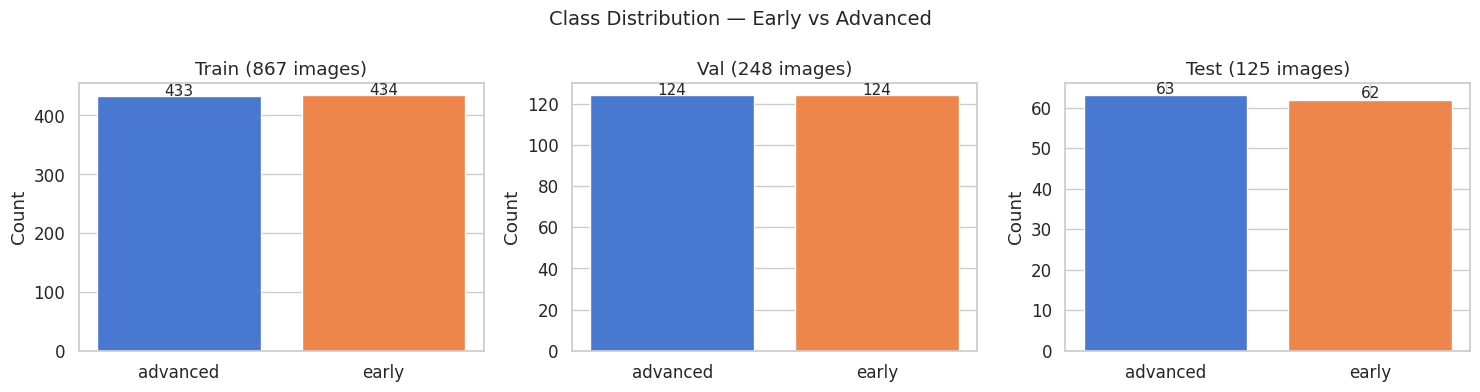

Train imbalance ratio: 1.00


In [8]:
split_data = {
    "Train": [all_labels[i] for i in train_idx],
    "Val": [all_labels[i] for i in val_idx],
    "Test": [all_labels[i] for i in test_idx],
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (split_name, lbls) in zip(axes, split_data.items()):
    counts = [lbls.count(v) for v in range(n_classes)]
    bars = ax.bar(class_names, counts, color=sns.color_palette("muted", n_classes))
    ax.set_title(f"{split_name} ({len(lbls)} images)")
    ax.set_ylabel("Count")
    for bar, v in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.5, str(v), ha="center", fontsize=11)

plt.suptitle("Class Distribution — Early vs Advanced", fontsize=14)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

train_counts = [split_data["Train"].count(v) for v in range(n_classes)]
ratio = max(train_counts) / (min(train_counts) or 1)
flag  = "⚠️ consider class weights" if ratio > 2.0 else ""
print(f"Train imbalance ratio: {ratio:.2f}{flag}")

## 5. Custom Heads, Model Builder, Optimizer, Scheduler, Freeze Helpers & Early Stopping

### Custom heads

All three heads receive raw backbone feature tensors **before pooling**, so they control how spatial information is aggregated:

- **`MultiStageHead`** - Global Average Pooling -> BN -> ReLU -> MLP -> logit. Lightweight, strong baseline.
- **`SpatialAttentionHead`** - Flattens `[B, C, H, W]` spatial grid into a sequence, applies multi-head self attention, means-pools, then linear -> logit. Learns which spatial regions to focus on.
- **`AttentionHead`** - Self-attention pooling with Layer Norm, outputs single logit. Simpler attention variant.

  ### Backbone feature extractor

  To feed raw feature maps to the custom heads, we strip the backbone's classifier/pooling layers and wrap it with a `BackboneWithHead` module. Standard `linear` and `mlp` heads use the orginal approach (replace final linear layer).




In [9]:
# Classification Heads


class LinearHead(nn.Module):
    """GAP (for CNNs) → Dropout → Linear → single logit."""
    def __init__(self, in_features, num_classes=1, dropout=0.3):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(in_features, num_classes)

    def forward(self, x, labels=None):
        if x.dim() == 4:
            x = self.pool(x).squeeze(-1).squeeze(-1)
        return self.fc(self.dropout(x))


class MLPHead(nn.Module):
    """GAP → Dropout → FC → BN → ReLU → Dropout → FC."""
    def __init__(self, in_features, num_classes=1, hidden_dim=512, dropout=0.3):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.mlp = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_features, hidden_dim),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(hidden_dim),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, x, labels=None):
        if x.dim() == 4:
            x = self.pool(x).squeeze(-1).squeeze(-1)
        return self.mlp(x)


class MultiStageHead(nn.Module):
    """GAP → Dropout → FC → BN → ReLU → FC. Compact MLP."""
    def __init__(self, in_features, num_classes=1, dropout=0.5):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(in_features, in_features // 2)
        self.bn = nn.BatchNorm1d(in_features // 2)
        self.relu = nn.ReLU(inplace=True)
        self.fc2 = nn.Linear(in_features // 2, num_classes)

    def forward(self, x, labels=None):
        if x.dim() == 4:
            x = self.pool(x).squeeze(-1).squeeze(-1)
        return self.fc2(self.relu(self.bn(self.fc1(self.dropout(x)))))


class SpatialAttentionHead(nn.Module):
    """MHA over spatial grid [H,W] → mean pool → FC. CNN-only."""
    def __init__(self, in_features, num_classes=1, dropout=0.0, num_heads=4):
        super().__init__()
        while in_features % num_heads != 0 and num_heads > 1:
            num_heads -= 1
        self.attn = nn.MultiheadAttention(in_features, num_heads, batch_first=True)
        self.norm = nn.LayerNorm(in_features)
        self.fc = nn.Sequential(nn.Dropout(dropout), nn.Linear(in_features, num_classes))

    def forward(self, x, labels=None):
        if x.dim() != 4:
            raise ValueError(f"SpatialAttentionHead expects [B,C,H,W], got {x.shape}")
        B, C, H, W = x.shape
        x = x.flatten(2).transpose(1, 2) # [B, HW, C]
        x, _ = self.attn(x, x, x)
        return self.fc(self.norm(x).mean(1))


class AttentionHead(nn.Module):
    """MHA + LayerNorm pool. Handles [B,C,H,W] and [B,D]."""
    def __init__(self, in_features, num_classes=1, num_heads=4, dropout=0.3):
        super().__init__()
        while in_features % num_heads != 0 and num_heads > 1:
            num_heads -= 1
        self.attn = nn.MultiheadAttention(in_features, num_heads, dropout=dropout, batch_first=True)
        self.norm = nn.LayerNorm(in_features)
        self.fc = nn.Linear(in_features, num_classes)

    def forward(self, x, labels=None):
        if x.dim() == 4:
            B, C, H, W = x.shape
            x = x.flatten(2).transpose(1, 2) # [B, HW, C]
        elif x.dim() == 2:
            x = x.unsqueeze(1) # [B, 1, D]
        else:
            raise ValueError(f"AttentionHead: unsupported shape {x.shape}")
        x, _ = self.attn(x, x, x)
        return self.fc(self.norm(x.mean(1)))


class CosFaceHead(nn.Module):
    """
    CosFace (additive cosine margin) head.
    Output: scaled cosine logits [B, num_classes].
    Use with CrossEntropyLoss.

    Training  → forward(features, labels)  applies the margin to the ground-truth class.
    Inference → forward(features) returns raw scaled logits.
    """
    def __init__(self, in_features, num_classes=2, scale=30.0, margin=0.35):
        super().__init__()
        self.scale = scale
        self.margin = margin
        self.weight = nn.Parameter(torch.FloatTensor(num_classes, in_features))
        nn.init.xavier_uniform_(self.weight)

    def forward(self, x, labels=None):
        if x.dim() == 4:
            x = x.mean(dim=[2, 3]) # GAP fallback
        x = F.normalize(x, dim=1)
        w = F.normalize(self.weight, dim=1)
        cosine = F.linear(x, w) # [B, num_classes]
        if labels is not None:
            one_hot = torch.zeros_like(cosine)
            one_hot.scatter_(1, labels.long().view(-1, 1), 1.0)
            cosine = cosine - one_hot * self.margin
        return cosine * self.scale


class ArcFaceHead(nn.Module):
    """
    ArcFace (additive angular margin) head.
    Output: scaled cosine logits [B, num_classes].
    Use with CrossEntropyLoss.

    Training  → forward(features, labels) adds the angular margin before scaling.
    Inference → forward(features) returns raw scaled logits.
    """
    def __init__(self, in_features, num_classes=2, scale=30.0, margin=0.5):
        super().__init__()
        self.scale = scale
        self.margin = margin
        self.weight = nn.Parameter(torch.randn(num_classes, in_features))
        nn.init.xavier_uniform_(self.weight)

    def forward(self, x, labels=None):
        if x.dim() == 4:
            x = x.mean(dim=[2, 3])
        x = F.normalize(x, dim=1)
        w = F.normalize(self.weight, dim=1)
        logits = F.linear(x, w) # [B, num_classes]
        if labels is None:
            return logits * self.scale
        theta = torch.acos(torch.clamp(logits, -1.0 + 1e-7, 1.0 - 1e-7))
        target_logits = torch.cos(theta + self.margin)
        one_hot = torch.zeros_like(logits)
        one_hot.scatter_(1, labels.long().view(-1, 1), 1.0)
        logits = logits * (1 - one_hot) + target_logits * one_hot
        return logits * self.scale


print("All heads defined.")

All heads defined.


In [10]:
# Model zoo — friendly key → timm full name


TIMM_MODELS = {
    "convnextv2_tiny": "convnextv2_tiny.fcmae_ft_in22k_in1k",
    "convnextv2_base": "convnextv2_base.fcmae_ft_in22k_in1k",
    "convnextv2_large": "convnextv2_large.fcmae_ft_in22k_in1k",
    "vit_large_224": "vit_large_patch32_224.orig_in21k",
    "deit3_large_224":  "deit3_large_patch16_224.fb_in22k_ft_in1k",
    "eva02_small_224": "eva02_small_patch14_224.mim_in22k",
    "beit_large_224": "beit_large_patch16_224",
    "coatnet_7": "coatnet_rmlp_2_rw_384.sw_in12k_ft_in1k",
    "efficientnetv2_l": "tf_efficientnetv2_l.in21k_ft_in1k",
    "nfnet_l0": "eca_nfnet_l0",
}

# Which block container to use for partial unfreezing (stage 1)
# Keys are the full timm names
MODEL_LAYERS_MAP = {
    "convnextv2_tiny.fcmae_ft_in22k_in1k": "stages",
    "convnextv2_base.fcmae_ft_in22k_in1k": "stages",
    "convnextv2_large.fcmae_ft_in22k_in1k": "stages",
    "vit_large_patch32_224.orig_in21k": "blocks",
    "deit3_large_patch16_224.fb_in22k_ft_in1k": "blocks",
    "eva02_small_patch14_224.mim_in22k": "blocks",
    "beit_large_patch16_224": "blocks",
    "coatnet_rmlp_2_rw_384.sw_in12k_ft_in1k": "stages",
    "tf_efficientnetv2_l.in21k_ft_in1k": "blocks",
    "eca_nfnet_l0": "stages",
}


def build_model(
    model_name: str,
    num_classes: int = 1,
    dropout: float = 0.3,
    head_type: str = "linear",
    scale: float = 30.0,
    margin: float = 0.35,
    num_heads: int = 8,
):
    """
    Builds a backbone (timm or torchvision) and attaches the chosen head.

    For timm models:  backbone loaded with num_classes=0 (feature extractor),
                      head attached as model.head.
    For torchvision:  final layer replaced as before.

    CosFace / ArcFace: num_classes should be 2 for binary classification.
    """
    if isinstance(head_type, tuple):
        head_type = head_type[0]

    # Torchvision model zoo
    TV_WEIGHTS = {
        "EfficientNet_B0": models.EfficientNet_B0_Weights.IMAGENET1K_V1,
        "EfficientNet_B1": models.EfficientNet_B1_Weights.IMAGENET1K_V2,
        "EfficientNet_B4": models.EfficientNet_B4_Weights.IMAGENET1K_V1,
        "EfficientNet_B7": models.EfficientNet_B7_Weights.IMAGENET1K_V1,
        "EfficientNet_V2_L": models.EfficientNet_V2_L_Weights.IMAGENET1K_V1,
        "ViT_B_16": models.ViT_B_16_Weights.IMAGENET1K_V1,
        "MaxVit_T": models.MaxVit_T_Weights.IMAGENET1K_V1,
        "Wide_ResNet50_2": models.Wide_ResNet50_2_Weights.IMAGENET1K_V2,
        "ResNet50": models.ResNet50_Weights.IMAGENET1K_V2,
        "ResNet152": models.ResNet152_Weights.IMAGENET1K_V2,
        "Swin_V2_S": models.Swin_V2_S_Weights.IMAGENET1K_V1,
        "Swin_V2_T": models.Swin_V2_T_Weights.IMAGENET1K_V1,
        "ConvNeXt_Tiny": models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1,
        "ConvNeXt_Base": models.ConvNeXt_Base_Weights.IMAGENET1K_V1,
        "ConvNeXt_Large": models.ConvNeXt_Large_Weights.IMAGENET1K_V1,
        "RegNet_Y_8GF": models.RegNet_Y_8GF_Weights.IMAGENET1K_V2,
        "RegNet_Y_16GF": models.RegNet_Y_16GF_Weights.IMAGENET1K_SWAG_E2E_V1,
    }
    TV_FN = {
        "EfficientNet_B0": models.efficientnet_b0,
        "EfficientNet_B1": models.efficientnet_b1,
        "EfficientNet_B4": models.efficientnet_b4,
        "EfficientNet_B7": models.efficientnet_b7,
        "EfficientNet_V2_L": models.efficientnet_v2_l,
        "ViT_B_16":  models.vit_b_16,
        "MaxVit_T": models.maxvit_t,
        "Wide_ResNet50_2": models.wide_resnet50_2,
        "ResNet50": models.resnet50,
        "ResNet152":  models.resnet152,
        "Swin_V2_S":  models.swin_v2_s,
        "Swin_V2_T": models.swin_v2_t,
        "ConvNeXt_Tiny": models.convnext_tiny,
        "ConvNeXt_Base":  models.convnext_base,
        "ConvNeXt_Large": models.convnext_large,
        "RegNet_Y_8GF": models.regnet_y_8gf,
        "RegNet_Y_16GF": models.regnet_y_16gf,
    }

    HEADS = {
        "linear": LinearHead,
        "mlp": MLPHead,
        "multi_stage_head": MultiStageHead,
        "spatial_head": SpatialAttentionHead,
        "attention_head": AttentionHead,
        "cosface_head": CosFaceHead,
        "arcface_head": ArcFaceHead,
    }

    # Load backbone
    is_timm = model_name in TIMM_MODELS
    if is_timm:
        full_name = TIMM_MODELS[model_name]
        backbone = timm.create_model(full_name, pretrained=True, num_classes=0)
        in_features = backbone.num_features
        if hasattr(backbone, "set_grad_checkpointing"):
            backbone.set_grad_checkpointing(True)
            print(f"Gradient checkpointing enabled for {model_name}")
    elif model_name in TV_WEIGHTS:
        backbone = TV_FN[model_name](weights=TV_WEIGHTS[model_name])
        if model_name.startswith("ViT"):
            in_features = backbone.heads.head.in_features
        elif model_name.startswith("MaxVit"):
            in_features = backbone.classifier[5].in_features
        elif model_name.startswith("Conv"):
            in_features = backbone.classifier[2].in_features
        elif model_name.startswith("Swin"):
            in_features = backbone.head.in_features
        elif model_name.startswith("RegNet"):
            in_features = backbone.fc.in_features
        elif hasattr(backbone, "fc"):
            in_features = backbone.fc.in_features
        else:
            in_features = backbone.classifier[1].in_features
    else:
        raise ValueError(f"'{model_name}' not found in timm or torchvision zoo.")

    # Build head
    if head_type not in HEADS:
        raise ValueError(f"Unknown head_type '{head_type}'. Choose from: {list(HEADS)}")
    head_cls = HEADS[head_type]
    if head_type in ("cosface_head", "arcface_head"):
        head = head_cls(in_features=in_features, num_classes=num_classes,
                        scale=scale, margin=margin)
    elif head_type == "spatial_head":
        head = head_cls(in_features=in_features, num_classes=num_classes,
                        dropout=dropout, num_heads=num_heads)
    elif head_type == "attention_head":
        head = head_cls(in_features=in_features, num_classes=num_classes,
                        num_heads=num_heads, dropout=dropout)
    else:
        head = head_cls(in_features=in_features, num_classes=num_classes, dropout=dropout)

    # Attach head 
    if is_timm:
        backbone.head = head   # timm convention: model.head
    elif model_name.startswith("ViT"):
        backbone.heads.head = head
    elif model_name.startswith("MaxVit"):
        backbone.classifier[5] = head
    elif model_name.startswith("Conv"):
        backbone.classifier[2] = head
    elif model_name.startswith("Swin"):
        backbone.head = head
    elif model_name.startswith("RegNet"):
        backbone.fc = head
    elif hasattr(backbone, "fc"):
        backbone.fc = head
    else:
        backbone.classifier = head

    print(f"Built '{model_name}' | in_features={in_features} | head='{head_type}' | num_classes={num_classes}")
    return backbone


print("build_model defined.")

build_model defined.


In [11]:
# Optimizer & Scheduler


def build_optimizer(name, parameters, params=None):
    p = dict(params or {})
    if name == "AdamW": return optim.AdamW(parameters, **p)
    if name == "RAdam": return optim.RAdam(parameters, **p)
    if name == "AdamP": return AdamP(parameters, **p)
    if name == "Lion": return Lion(parameters, **p)
    if name == "SGD": return optim.SGD(parameters, **p)
    raise ValueError(f"Unknown optimizer: {name}")


def build_scheduler(name, optimizer, num_epochs=None, params=None):
    p = dict(params or {})
    if name == "CosineAnnealingLR":
        if "T_max" not in p and num_epochs: p["T_max"] = num_epochs
        return optim.lr_scheduler.CosineAnnealingLR(optimizer, **p)
    if name == "ReduceLROnPlateau":
        return optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", **p)
    if name == "StepLR":
        return optim.lr_scheduler.StepLR(optimizer, **p)
    if name == "ExponentialLR":
        return optim.lr_scheduler.ExponentialLR(optimizer, **p)
    raise ValueError(f"Unknown scheduler: {name}")


# Freeze / Unfreeze helpers


def set_requires_grad(model, flag):
    for p in model.parameters(): p.requires_grad = flag


def freeze_backbone_except_head(model):
    """
    Freeze everything, then unfreeze any module whose name contains
    'head', 'fc', or 'classifier'. Works for timm and torchvision
    without model-specific branching.
    """
    set_requires_grad(model, False)
    head_names = []
    for name, module in model.named_modules():
        if any(k in name for k in ("head", "fc", "classifier")):
            set_requires_grad(module, True)
            head_names.append(name)
    if head_names:
        print(f"Backbone frozen. Trainable head modules: {head_names}")
    else:
        print("⚠️ No head module found — check model architecture.")
    n_trainable = sum(p.requires_grad for p in model.parameters())
    print(f"{n_trainable} trainable parameters.")


def unfreeze_stage(model, model_name: str, stage: int, num_blocks: int = 1):
    """
    Stage 2 → full model trainable.
    Stage 1 → unfreeze last `num_blocks` from the block container
              specified in MODEL_LAYERS_MAP, plus always keep head trainable.
    `model_name` is the friendly key; the function resolves the full timm name
    via TIMM_MODELS for the layer map lookup.
    """
    if stage == 2:
        print("Unfreezing full backbone.")
        set_requires_grad(model, True)
        return

    # Resolve full name for MODEL_LAYERS_MAP lookup
    full_name = TIMM_MODELS.get(model_name, model_name).lower()
    block_attr = MODEL_LAYERS_MAP.get(full_name)

    # Freeze everything first, then selectively unfreeze
    set_requires_grad(model, False)

    if block_attr is None:
        # Torchvision fallback — unfreeze last features/layer
        for attr in ("features", "layer4", "blocks"):
            container = getattr(model, attr, None)
            if container is not None:
                blocks = list(container.children())
                for blk in blocks[-num_blocks:]:
                    set_requires_grad(blk, True)
                print(f"Unfroze last {num_blocks} from '{attr}' (torchvision fallback).")
                break
    else:
        container = getattr(model, block_attr, None)
        if container is None:
            print(f"⚠️ Attribute '{block_attr}' not found on model.")
        else:
            blocks = list(container.children())
            for blk in blocks[-num_blocks:]:
                set_requires_grad(blk, True)
            print(f"Unfroze last {num_blocks} block(s) from '{block_attr}'.")

    # Head must always stay trainable
    for name, module in model.named_modules():
        if any(k in name for k in ("head", "fc", "classifier")):
            set_requires_grad(module, True)

    n_trainable = sum(p.requires_grad for p in model.parameters())
    print(f"Total trainable parameters after stage-1 unfreeze: {n_trainable}")



# Early Stopping


class EarlyStopping:
    """
    Monitors val_loss. Saves checkpoint when loss improves by > delta.
    Stops when no improvement for `patience` epochs.
    Counter resets on unfreeze events so newly unfrozen layers always
    get a fair window to train.
    """
    def __init__(self, patience=10, delta=1e-4, path="checkpoint.pth", verbose=True):
        self.patience = patience
        self.delta = delta
        self.path = path
        self.verbose = verbose
        self.counter = 0
        self.best_loss  = float("inf")
        self.early_stop = False

    def __call__(self, val_loss, model):
        if val_loss < (self.best_loss - self.delta):
            if self.verbose:
                print(f"✅ val_loss {self.best_loss:.4f} -> {val_loss:.4f} (checkpoint saved)")
            self.best_loss = val_loss
            self.counter = 0
            torch.save(model.state_dict(), self.path)
            return True
        else:
            self.counter += 1
            if self.verbose:
                print(f"No improvement {self.counter}/{self.patience}  (best={self.best_loss:.4f})")
            if self.counter >= self.patience:
                self.early_stop = True
                print(f"🛑 Early stopping triggered.")
            return False


print("All helpers defined.")

All helpers defined.


## 6. Training Loop

Key behaviours:

* **Standard heads** (`linear`, `mlp`...) - `BCEWithLogitsLoss`, float labels `[B, 1]`, `sigmoid` for probs.
* **Margin heads** (`cosface_head`, `arcface_head`) - `CrossEntropyLoss`, long labels `[B]`, model receives labels during the **training forward pass** for margin injection, `softmax[:. 1]` for probs during validation and evaluation.
* Early stopping counter resets after each unfreeze evenet.
* `timm.get_pretrained_cfg` is used to pull model specific mean/std/img_size automatically 

In [12]:
# Resolve image size and normalisation from timm config 
IMG_SIZE = 224
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

if MODEL_NAME in TIMM_MODELS:
    full_timm_name = TIMM_MODELS[MODEL_NAME]
    try:
        cfg = timm.get_pretrained_cfg(full_timm_name)
        IMG_SIZE = cfg.input_size[-1]
        MEAN  = list(cfg.mean)
        STD  = list(cfg.std)
        print(f"timm config → img_size={IMG_SIZE}, mean={MEAN}, std={STD}")
    except Exception as e:
        print(f"Could not fetch timm config ({e}). Using ImageNet defaults.")
else:
    print(f"Torchvision model — using ImageNet defaults: img_size={IMG_SIZE}")

# Transforms
train_transforms = A.Compose([
    A.Resize(IMG_SIZE + 32, IMG_SIZE + 32),
    A.RandomCrop(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=10, p=0.5, border_mode=0),
    A.ColorJitter(brightness=0.1, contrast=0.1, p=0.5),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])
val_test_transforms = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])

#  DataLoaders 
num_workers = min(4, os.cpu_count() or 1)
loader_kw   = dict(
    batch_size=BATCH_SIZE, pin_memory=torch.cuda.is_available(),
    num_workers=num_workers, persistent_workers=False,
    prefetch_factor=2 if num_workers > 0 else None,
)
train_loader = DataLoader(
    TransformedDataset(Subset(full_dataset, train_idx), train_transforms),
    shuffle=True, **loader_kw
)
val_loader = DataLoader(
    TransformedDataset(Subset(full_dataset, val_idx), val_test_transforms),
    shuffle=False, **loader_kw
)
test_loader = DataLoader(
    TransformedDataset(Subset(full_dataset, test_idx), val_test_transforms),
    shuffle=False, **loader_kw
)
print(f"Batches — train: {len(train_loader)} | val: {len(val_loader)} | test: {len(test_loader)}")

Torchvision model — using ImageNet defaults: img_size=224
Batches — train: 55 | val: 16 | test: 8


In [13]:
# Accelerator, model, loss, early stopping
accelerator = Accelerator(mixed_precision="fp16")
device = accelerator.device

BEST_WEIGHTS_PATH = (
    f"{OUTPUT_DIR}/best_{MODEL_NAME}_{HEAD_TYPE}_{OPTIMIZER_NAME}_{SCHEDULER_NAME}.pth"
)

model = build_model(
    MODEL_NAME, num_classes=NUM_CLASSES, dropout=DROPOUT,
    head_type=HEAD_TYPE, scale=SCALE, margin=MARGIN, num_heads=ATTN_NUM_HEADS,
)

# Loss function depends on head type
if IS_MARGIN_HEAD:
    loss_fn = nn.CrossEntropyLoss()
    print("Loss: CrossEntropyLoss (margin head - labels as long ints)")
else:
    loss_fn = nn.BCEWithLogitsLoss()
    print("Loss: BCEWithLogitsLoss (standard head - labels as float [B,1])")

early_stopping = EarlyStopping(
    patience=ES_PATIENCE, delta=ES_DELTA,
    path=BEST_WEIGHTS_PATH, verbose=True
)

freeze_backbone_except_head(model)
trainable = filter(lambda p: p.requires_grad, model.parameters())
optimizer = build_optimizer(OPTIMIZER_NAME, trainable, {"lr": LR, "weight_decay": WEIGHT_DECAY})
scheduler = build_scheduler(SCHEDULER_NAME, optimizer, NUM_EPOCHS, SCHEDULER_PARAMS)

model, optimizer, train_loader, val_loader, scheduler = accelerator.prepare(
    model, optimizer, train_loader, val_loader, scheduler
)

history = {"train_loss": [], "val_loss": [], "val_acc": []}
print(f"\nTraining on {device}")

Downloading: "https://download.pytorch.org/models/convnext_base-6075fbad.pth" to /root/.cache/torch/hub/checkpoints/convnext_base-6075fbad.pth


100%|██████████| 338M/338M [00:01<00:00, 209MB/s]  


Built 'ConvNeXt_Base' | in_features=1024 | head='mlp' | num_classes=1
Loss: BCEWithLogitsLoss (standard head - labels as float [B,1])
Backbone frozen. Trainable head modules: ['classifier', 'classifier.0', 'classifier.1', 'classifier.2', 'classifier.2.pool', 'classifier.2.mlp', 'classifier.2.mlp.0', 'classifier.2.mlp.1', 'classifier.2.mlp.2', 'classifier.2.mlp.3', 'classifier.2.mlp.4', 'classifier.2.mlp.5']
8 trainable parameters.

Training on cuda


In [14]:
# Training loop 
for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    print("─" * 52)

    # Gradual unfreezing 
    unwrapped = accelerator.unwrap_model(model)
    for stage, trigger in [(1, UNFREEZE_EPOCH_STAGE1), (2, UNFREEZE_EPOCH_STAGE2)]:
        if trigger is not None and epoch + 1 == trigger:
            unfreeze_stage(unwrapped, MODEL_NAME, stage=stage, num_blocks=NUM_BLOCKS_TO_UNFREEZE)
            trainable = filter(lambda p: p.requires_grad, unwrapped.parameters())
            optimizer = build_optimizer(OPTIMIZER_NAME, trainable, {"lr": LR, "weight_decay": WEIGHT_DECAY})
            scheduler = build_scheduler(SCHEDULER_NAME, optimizer, NUM_EPOCHS, SCHEDULER_PARAMS)
            model, optimizer, train_loader, val_loader, scheduler = accelerator.prepare(
                unwrapped, optimizer, train_loader, val_loader, scheduler
            )
            early_stopping.counter = 0
            print(f"Early stopping counter reset after stage-{stage} unfreeze.")

    # Train phase
    model.train()
    train_loss = 0.0
    for step, (inputs, labels) in enumerate(tqdm(train_loader, desc="  Train", leave=False)):
        inputs = inputs.to(device)

        with accelerator.accumulate(model):
            optimizer.zero_grad()
            if IS_MARGIN_HEAD:
                # Pass labels so CosFace/ArcFace can apply the angular margin
                labels_dev = labels.long().to(device)
                logits = model(inputs, labels_dev) # [B, 2]
                loss = loss_fn(logits, labels_dev)
            else:
                labels_dev = labels.float().unsqueeze(1).to(device)
                logits = model(inputs)  # [B, 1]
                loss = loss_fn(logits, labels_dev)

            accelerator.backward(loss)
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        train_loss += loss.item()
    avg_train_loss = train_loss / len(train_loader)

    #  Validation phase 
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in tqdm(val_loader, desc="  Val  ", leave=False):
            inputs = inputs.to(device)
            if IS_MARGIN_HEAD:
                labels_dev = labels.long().to(device)
                logits = model(inputs)   # no labels at val time
                loss  = loss_fn(logits, labels_dev)
                probs = torch.softmax(logits, dim=1)[:, 1] # prob of positive class
                preds = logits.argmax(dim=1)
                val_correct += (preds == labels_dev).sum().item()
            else:
                labels_dev = labels.float().unsqueeze(1).to(device)
                logits = model(inputs)
                loss = loss_fn(logits, labels_dev)
                preds = (torch.sigmoid(logits) >= BINARY_THRESHOLD).float()
                val_correct += (preds == labels_dev).sum().item()
            val_loss += loss.item()
            val_total += labels.size(0)

    avg_val_loss = val_loss / len(val_loader)
    val_acc = val_correct / val_total

    #  Scheduler step
    if SCHEDULER_NAME == "ReduceLROnPlateau":
        scheduler.step(avg_val_loss)
    else:
        scheduler.step()

    history["train_loss"].append(avg_train_loss)
    history["val_loss"].append(avg_val_loss)
    history["val_acc"].append(val_acc)

    print(f"train_loss={avg_train_loss:.4f} val_loss={avg_val_loss:.4f} val_acc={val_acc:.4f}")

    # Early stopping
    early_stopping(avg_val_loss, accelerator.unwrap_model(model))
    if early_stopping.early_stop:
        print(f"\nStopped at epoch {epoch+1}. Best val_loss: {early_stopping.best_loss:.4f}")
        break

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()

# Restore best weights 
print("\nRestoring best checkpoint…")
accelerator.unwrap_model(model).load_state_dict(
    torch.load(BEST_WEIGHTS_PATH, map_location=device)
)
print(f"Best weights loaded: {BEST_WEIGHTS_PATH}")
print(f"Epochs run: {len(history['train_loss'])} / {NUM_EPOCHS}")


Epoch 1/50
────────────────────────────────────────────────────


  Train:   0%|          | 0/55 [00:00<?, ?it/s]

  Val  :   0%|          | 0/16 [00:00<?, ?it/s]

train_loss=0.5182 val_loss=0.3159 val_acc=0.8871
✅ val_loss inf -> 0.3159 (checkpoint saved)

Epoch 2/50
────────────────────────────────────────────────────


  Train:   0%|          | 0/55 [00:00<?, ?it/s]

...

  Val  :   0%|          | 0/16 [00:00<?, ?it/s]

train_loss=0.1113 val_loss=0.4593 val_acc=0.9556
No improvement 9/10  (best=0.1002)

Epoch 18/50
────────────────────────────────────────────────────


  Train:   0%|          | 0/55 [00:00<?, ?it/s]

  Val  :   0%|          | 0/16 [00:00<?, ?it/s]

train_loss=0.1441 val_loss=0.8488 val_acc=0.9234
No improvement 10/10  (best=0.1002)
🛑 Early stopping triggered.

Stopped at epoch 18. Best val_loss: 0.1002

Restoring best checkpoint…
Best weights loaded: /kaggle/working/best_ConvNeXt_Base_mlp_AdamP_CosineAnnealingLR.pth
Epochs run: 18 / 50


## 7. Training Curve Analysis

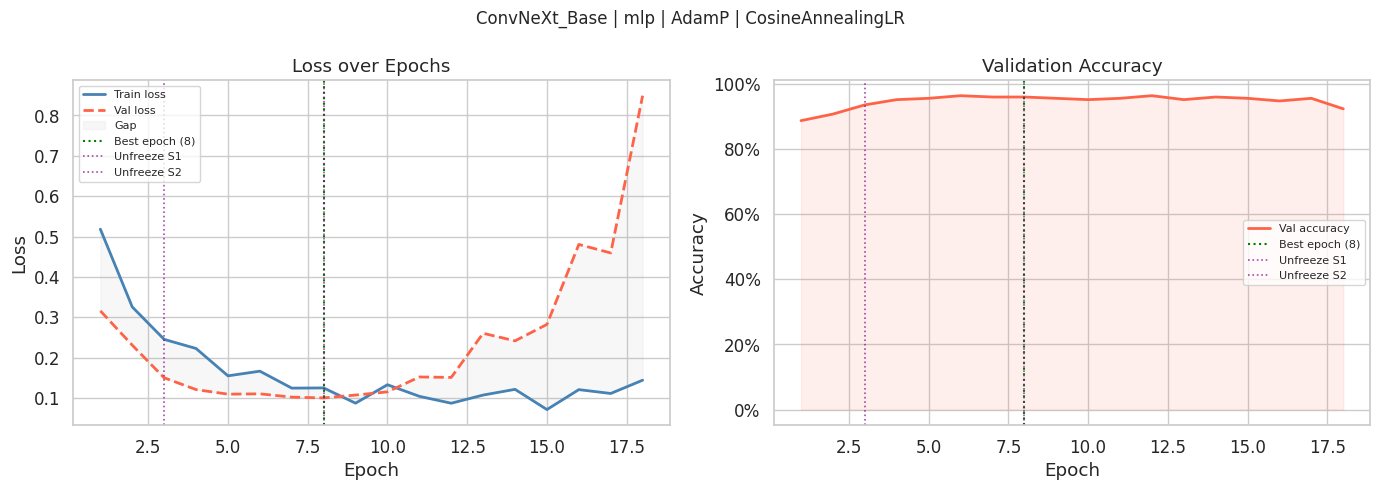

Best epoch: 8 | best val_loss: 0.1002


In [15]:
epochs_x = list(range(1, len(history["train_loss"]) + 1))
best_epoch = int(np.argmin(history["val_loss"])) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(epochs_x, history["train_loss"], label="Train loss",  lw=2, color="steelblue")
ax.plot(epochs_x, history["val_loss"], label="Val loss", lw=2, color="tomato", ls="--")
ax.fill_between(epochs_x, history["train_loss"], history["val_loss"],
                alpha=0.06, color="grey", label="Gap")
ax.axvline(best_epoch, color="green", ls=":", lw=1.5, label=f"Best epoch ({best_epoch})")
for ue, lab in [(UNFREEZE_EPOCH_STAGE1, "S1"), (UNFREEZE_EPOCH_STAGE2, "S2")]:
    if ue and ue <= len(epochs_x):
        ax.axvline(ue, color="purple", ls=":", lw=1.2, alpha=0.7, label=f"Unfreeze {lab}")
ax.set_title("Loss over Epochs"); ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(epochs_x, history["val_acc"], label="Val accuracy", lw=2, color="tomato")
ax.fill_between(epochs_x, history["val_acc"], alpha=0.1, color="tomato")
ax.axvline(best_epoch, color="green", ls=":", lw=1.5, label=f"Best epoch ({best_epoch})")
for ue, lab in [(UNFREEZE_EPOCH_STAGE1, "S1"), (UNFREEZE_EPOCH_STAGE2, "S2")]:
    if ue and ue <= len(epochs_x):
        ax.axvline(ue, color="purple", ls=":", lw=1.2, alpha=0.7, label=f"Unfreeze {lab}")
ax.set_title("Validation Accuracy"); ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
ax.legend(fontsize=8)

plt.suptitle(
    f"{MODEL_NAME} | {HEAD_TYPE} | {OPTIMIZER_NAME} | {SCHEDULER_NAME}", fontsize=12
)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Best epoch: {best_epoch} | best val_loss: {min(history['val_loss']):.4f}")

## 8.Evaluation - Confusion Matrix

Built 'ConvNeXt_Base' | in_features=1024 | head='mlp' | num_classes=1


Evaluating test set:   0%|          | 0/8 [00:00<?, ?it/s]

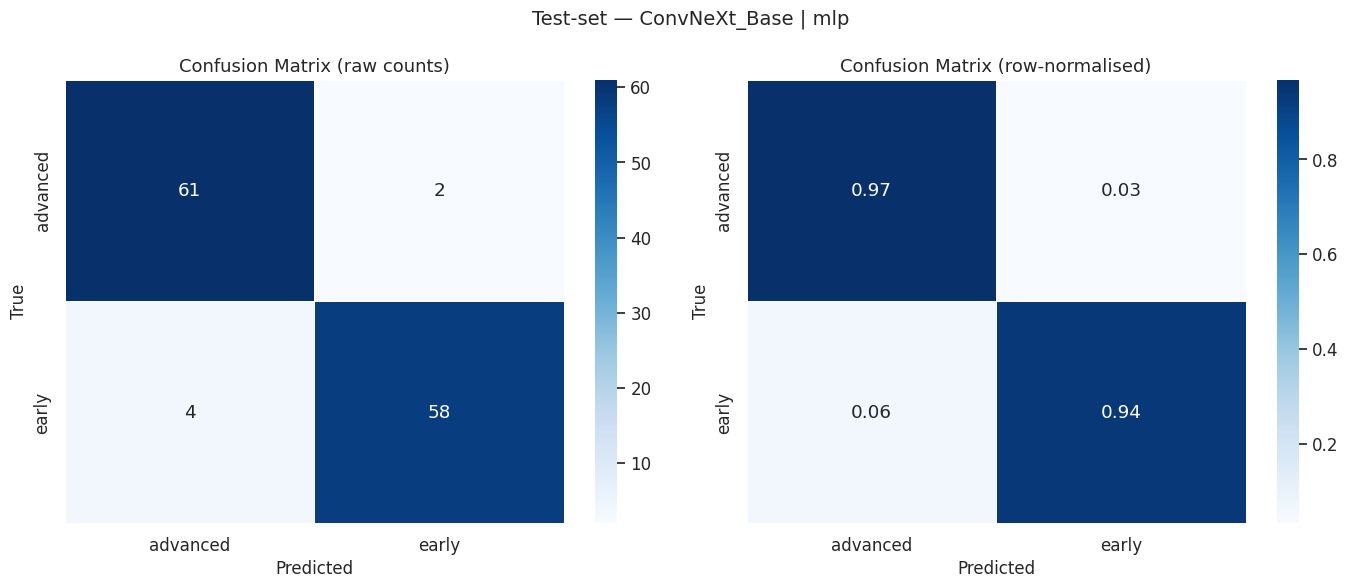

In [16]:
# Load best checkpoint into a clean model 
eval_model = build_model(
    MODEL_NAME, num_classes=NUM_CLASSES, dropout=DROPOUT,
    head_type=HEAD_TYPE, scale=SCALE, margin=MARGIN, num_heads=ATTN_NUM_HEADS,
)
eval_model.load_state_dict(torch.load(BEST_WEIGHTS_PATH, map_location="cpu"))
eval_model.eval().to(device)

raw_test_loader = DataLoader(
    TransformedDataset(Subset(full_dataset, test_idx), val_test_transforms),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=num_workers,
)

all_labels_test, all_probs_test = [], []
with torch.no_grad():
    for inputs, labels in tqdm(raw_test_loader, desc="Evaluating test set"):
        logits = eval_model(inputs.to(device))   # no labels → no margin
        if IS_MARGIN_HEAD:
            probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        else:
            probs = torch.sigmoid(logits.view(-1)).cpu().numpy()
        all_probs_test.extend(probs.tolist())
        all_labels_test.extend(labels.numpy().tolist())

all_probs_test = np.array(all_probs_test)
all_labels_test = np.array(all_labels_test)
all_preds_test = (all_probs_test >= BINARY_THRESHOLD).astype(int)

cm_raw  = confusion_matrix(all_labels_test, all_preds_test)
cm_norm = cm_raw.astype(float) / cm_raw.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, cm, title, fmt in zip(
    axes,
    [cm_raw, cm_norm],
    ["Confusion Matrix (raw counts)", "Confusion Matrix (row-normalised)"],
    ["d", ".2f"]
):
    sns.heatmap(cm, annot=True, fmt=fmt, cmap="Blues",
                xticklabels=class_names, yticklabels=class_names,
                linewidths=0.5, ax=ax)
    ax.set_xlabel("Predicted", fontsize=12)
    ax.set_ylabel("True", fontsize=12)
    ax.set_title(title, fontsize=13)
plt.suptitle(f"Test-set — {MODEL_NAME} | {HEAD_TYPE}", fontsize=14)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Evaluation - Full Classification Report 

In [21]:
print("=" * 55)
print("CLASSIFICATION REPORT — TEST SET")
print("=" * 55)
print(classification_report(all_labels_test, all_preds_test,
                             target_names=class_names, digits=4))

summary = {
    "Accuracy": accuracy_score(all_labels_test, all_preds_test),
    "Macro Precision": precision_score(all_labels_test, all_preds_test, average="macro", zero_division=0),
    "Macro Recall": recall_score(all_labels_test, all_preds_test, average="macro", zero_division=0),
    "Macro F1": f1_score(all_labels_test, all_preds_test, average="macro", zero_division=0),
    "Weighted F1": f1_score(all_labels_test, all_preds_test, average="weighted", zero_division=0),
}
df = pd.DataFrame(summary.items(), columns=["Metric", "Value"])
df["Value"] = df["Value"].map("{:.4f}".format)
display(df.set_index("Metric"))
df.to_csv(f"{OUTPUT_DIR}/metrics_summary.csv", index=False)

CLASSIFICATION REPORT — TEST SET
              precision    recall  f1-score   support

    advanced     0.9385    0.9683    0.9531        63
       early     0.9667    0.9355    0.9508        62

    accuracy                         0.9520       125
   macro avg     0.9526    0.9519    0.9520       125
weighted avg     0.9525    0.9520    0.9520       125



,Value
Metric,
Accuracy,0.9520
Macro Precision,0.9526
Macro Recall,0.9519
Macro F1,0.9520
Weighted F1,0.9520


## 10. Evaluation - ROC Curve & AUC with Youden Threshold

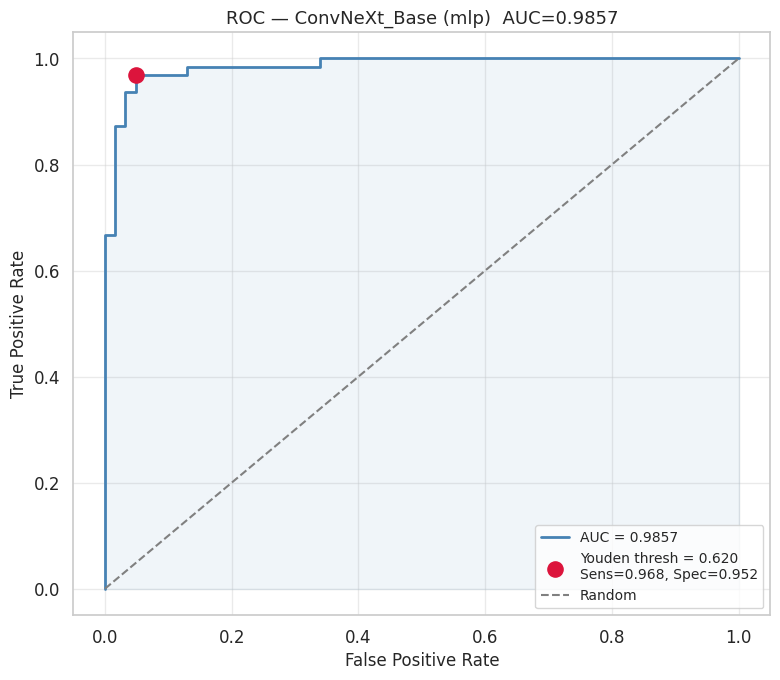

AUC-ROC : 0.9857
Youden threshold: 0.6197

At Youden threshold:
Accuracy : 0.9600
Macro F1 : 0.9600
Recall : 0.9683
Precision: 0.9531


In [18]:
# Positive class = Advanced (index 1 if sorted alphabetically, else whichever is higher)
pos_name = next((c for c in class_names if "adv" in c.lower()), class_names[1])
pos_class_idx = full_dataset.class_to_idx[pos_name]
pos_probs = all_probs_test if pos_class_idx == 1 else (1 - all_probs_test)
binary_labels = (all_labels_test == pos_class_idx).astype(int)

fpr, tpr, thresholds = roc_curve(binary_labels, pos_probs)
auc_val = roc_auc_score(binary_labels, pos_probs)
youden_idx = int(np.argmax(tpr - fpr))
youden_thresh = float(thresholds[youden_idx])

fig, ax = plt.subplots(figsize=(8, 7))
ax.plot(fpr, tpr, lw=2, color="steelblue", label=f"AUC = {auc_val:.4f}")
ax.fill_between(fpr, tpr, alpha=0.08, color="steelblue")
ax.scatter(fpr[youden_idx], tpr[youden_idx], s=120, color="crimson", zorder=5,
           label=f"Youden thresh = {youden_thresh:.3f}\n"
                 f"Sens={tpr[youden_idx]:.3f}, Spec={1-fpr[youden_idx]:.3f}")
ax.plot([0, 1], [0, 1], "--", color="grey", lw=1.5, label="Random")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title(f"ROC — {MODEL_NAME} ({HEAD_TYPE})  AUC={auc_val:.4f}", fontsize=13)
ax.legend(fontsize=10, loc="lower right")
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"AUC-ROC : {auc_val:.4f}")
print(f"Youden threshold: {youden_thresh:.4f}")
p_y = (pos_probs >= youden_thresh).astype(int)
print(f"\nAt Youden threshold:")
print(f"Accuracy : {accuracy_score(binary_labels, p_y):.4f}")
print(f"Macro F1 : {f1_score(binary_labels, p_y, average='macro'):.4f}")
print(f"Recall : {recall_score(binary_labels, p_y):.4f}")
print(f"Precision: {precision_score(binary_labels, p_y):.4f}")

## 11. Evaluation - Threshold Sensitivity Analysis

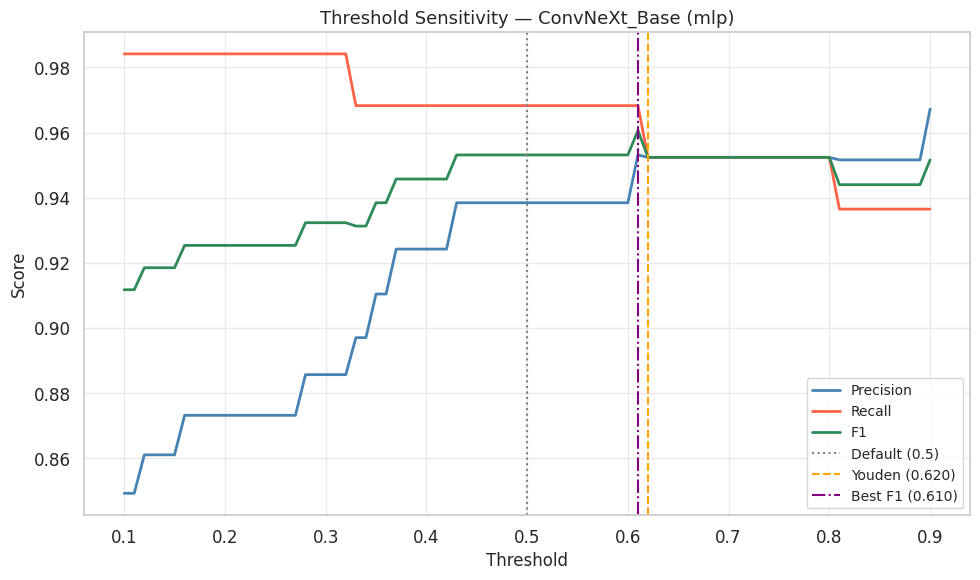

Best-F1 threshold: 0.61  F1=0.9606


In [19]:
thresh_range  = np.linspace(0.1, 0.9, 81)
precisions, recalls, f1s = [], [], []
for t in thresh_range:
    pt = (pos_probs >= t).astype(int)
    precisions.append(precision_score(binary_labels, pt, zero_division=0))
    recalls.append(recall_score(binary_labels, pt, zero_division=0))
    f1s.append(f1_score(binary_labels, pt, zero_division=0))

best_f1_idx = int(np.argmax(f1s))
best_f1_thresh = float(thresh_range[best_f1_idx])

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(thresh_range, precisions, label="Precision", lw=2, color="steelblue")
ax.plot(thresh_range, recalls, label="Recall", lw=2, color="tomato")
ax.plot(thresh_range, f1s, label="F1", lw=2, color="seagreen")
ax.axvline(BINARY_THRESHOLD, color="grey", ls=":", lw=1.5, label=f"Default ({BINARY_THRESHOLD})")
ax.axvline(youden_thresh, color="orange", ls="--", lw=1.5, label=f"Youden ({youden_thresh:.3f})")
ax.axvline(best_f1_thresh, color="purple", ls="-.", lw=1.5, label=f"Best F1 ({best_f1_thresh:.3f})")
ax.set_xlabel("Threshold",fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title(f"Threshold Sensitivity — {MODEL_NAME} ({HEAD_TYPE})", fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/threshold_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Best-F1 threshold: {best_f1_thresh:.2f}  F1={f1s[best_f1_idx]:.4f}")

## 12. Model Export & Summary

In [22]:
final_path = (
    f"{OUTPUT_DIR}/final_{MODEL_NAME}_{HEAD_TYPE}_{OPTIMIZER_NAME}_{SCHEDULER_NAME}.pth"
)
torch.save(accelerator.unwrap_model(model).state_dict(), final_path)

print("=" * 60)
print("TRAINING & EVALUATION SUMMARY — Early vs Advanced")
print("=" * 60)
print(f"Model : {MODEL_NAME}")
print(f"  Head : {HEAD_TYPE}  |  Dropout: {DROPOUT}")
print(f"Margin head : {IS_MARGIN_HEAD}"
      + (f" (scale={SCALE}, margin={MARGIN})" if IS_MARGIN_HEAD else ""))
print(f"Optimizer : {OPTIMIZER_NAME} | LR={LR:.2e} | WD={WEIGHT_DECAY:.2e}")
print(f"Scheduler : {SCHEDULER_NAME}")
print(f"img_size : {IMG_SIZE}")
print(f"Epochs run : {len(history['train_loss'])} / {NUM_EPOCHS}")
print(f"Best epoch : {best_epoch} (val_loss={min(history['val_loss']):.4f})")
print(f"Early stop patience : {ES_PATIENCE}")
print()
print(f"Test set size : {len(all_labels_test)}")
print(f"Threshold used : {BINARY_THRESHOLD}")
print()
print(f"Accuracy : {accuracy_score(all_labels_test, all_preds_test):.4f}")
print(f"Macro F1 : {f1_score(all_labels_test, all_preds_test, average='macro'):.4f}")
print(f"Weighted F1 : {f1_score(all_labels_test, all_preds_test, average='weighted'):.4f}")
print(f"AUC-ROC : {auc_val:.4f}")
print(f"Youden threshold : {youden_thresh:.4f}")
print(f"Best-F1 threshold : {best_f1_thresh:.4f}")
print()
print("Saved artefacts:")
for fname in [
    "class_distribution.png", "training_curves.png",
    "confusion_matrices.png", "roc_curve.png",
    "threshold_sensitivity.png", "sample_predictions.png",
    "metrics_summary.csv",
    Path(BEST_WEIGHTS_PATH).name,
    Path(final_path).name,
]:
    p = Path(OUTPUT_DIR) / fname
    print(f"{'✅' if p.exists() else '❌'}  {fname}")

TRAINING & EVALUATION SUMMARY — Early vs Advanced
Model : ConvNeXt_Base
  Head : mlp  |  Dropout: 0.10250626247755007
Margin head : False
Optimizer : AdamP | LR=3.36e-05 | WD=7.29e-03
Scheduler : CosineAnnealingLR
img_size : 224
Epochs run : 18 / 50
Best epoch : 8 (val_loss=0.1002)
Early stop patience : 10

Test set size : 125
Threshold used : 0.5

Accuracy : 0.9520
Macro F1 : 0.9520
Weighted F1 : 0.9520
AUC-ROC : 0.9857
Youden threshold : 0.6197
Best-F1 threshold : 0.6100

Saved artefacts:
✅  class_distribution.png
✅  training_curves.png
✅  confusion_matrices.png
✅  roc_curve.png
✅  threshold_sensitivity.png
✅  sample_predictions.png
✅  metrics_summary.csv
✅  best_ConvNeXt_Base_mlp_AdamP_CosineAnnealingLR.pth
✅  final_ConvNeXt_Base_mlp_AdamP_CosineAnnealingLR.pth
